# **Chapter 2 – Individual Exercise 1: Decision Tree**

Sybmitted by:- Vikrant Singh Thakur

The assignment is split in six phases as follows:-

1. Phase 1 :- File readings and establishing the dataset as to what we will use as a target and aslo splitting training and testing data also visualizing the RAW data we are dealing with.

2. Phase 2:- Missing values handling and preprocessing such as converting categories to numerics using encoding.

3. Phase 3:- Decesion Tree Regressor.

4. Phase 4:- Random Forest Regressor.

5. Phase 5:- Extra Tree Regressor.

6. Phase 6:- Comparisons.

# **PHASE 1:-**

**Step 1:-**

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

**Step 2:-** (Uploading the local file and setting the view settings)

In [125]:
upload=files.upload("")
import io
data=pd.read_csv('train 1 (1).csv')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

Saving train 1 (1).csv to train 1 (1) (5).csv


**Step 3:-**

(Finding out what actually is in the csv and figuring out the data we are dealing with)

**Step 3.1:-** (data.shape)

In [126]:
print("The shape of data:- ")
print(data.shape)

The shape of data:- 
(1460, 81)


**Step 3.2 :-**  (data.describe)

In [127]:
print("output for data.describe :- ")
print(data.describe)

Streaming output truncated to the last 5000 lines.
846           Unf           2         425         TA         TA          Y   
847           Unf           1         338         TA         TA          Y   
848           Unf           2         360         Fa         TA          Y   
849           RFn           2         512         TA         TA          Y   
850           Fin           2         420         TA         TA          Y   
851           Fin           2         400         TA         TA          Y   
852           Unf           1         240         TA         TA          Y   
853           RFn           2         645         TA         TA          Y   
854           Unf           2         454         TA         TA          Y   
855           Unf           1         260         TA         TA          Y   
856           Unf           2         576         TA         Fa          Y   
857           Fin           2         343         TA         TA          Y   
858          

**Step 3.3:-** data.head(20)

In [128]:
print("Output for data.head(20) :- ")
print(data.head(20))

Output for data.head(20) :- 
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0    1          60       RL         65.0     8450   Pave   NaN      Reg   
1    2          20       RL         80.0     9600   Pave   NaN      Reg   
2    3          60       RL         68.0    11250   Pave   NaN      IR1   
3    4          70       RL         60.0     9550   Pave   NaN      IR1   
4    5          60       RL         84.0    14260   Pave   NaN      IR1   
5    6          50       RL         85.0    14115   Pave   NaN      IR1   
6    7          20       RL         75.0    10084   Pave   NaN      Reg   
7    8          60       RL          NaN    10382   Pave   NaN      IR1   
8    9          50       RM         51.0     6120   Pave   NaN      Reg   
9   10         190       RL         50.0     7420   Pave   NaN      Reg   
10  11          20       RL         70.0    11200   Pave   NaN      Reg   
11  12          60       RL         85.0    11924   Pave   NaN      IR1

**Step 3.4:-** (Datatypes in the dataset)

In [129]:
print(data.dtypes)

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


**Step 3.5:-**

1. After step 3.4, we can safely colclude that we are dealing with int64, float64 and object datatypes.
2. We will be dealing with float64 as well since it would be better to just get an int64 since its easier.

**Step 3.6:-**

1. Separating SalesPrice as the target.

2. Verifying.

In [130]:
target=data['SalePrice']
predictionSet=data.drop(columns="SalePrice")
print(target.shape)
print(predictionSet.shape)

(1460,)
(1460, 80)


**Step 4:-**

Mssing values and visual representation:-

Electrical         1
MasVnrArea         8
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageYrBlt       81
GarageFinish      81
GarageCond        81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64


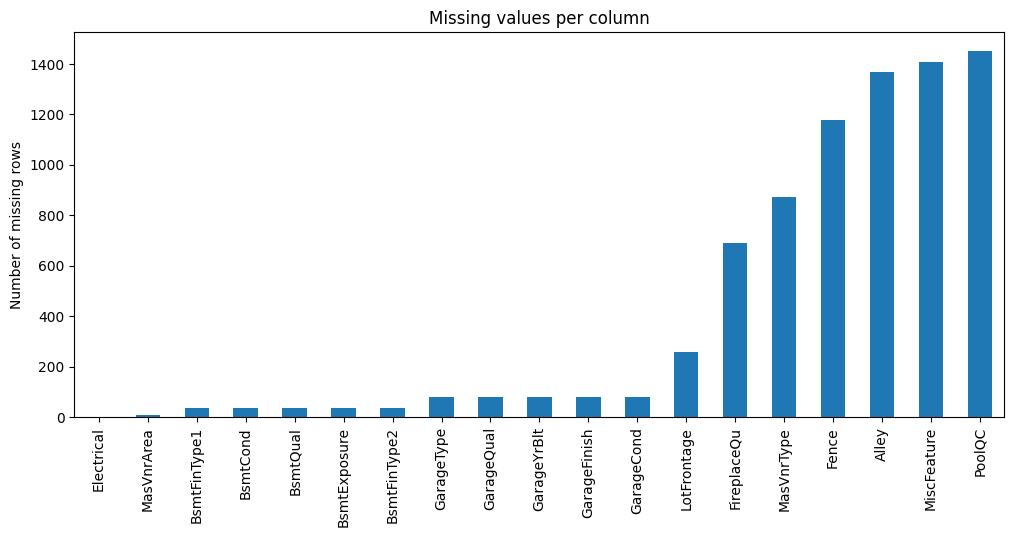

In [131]:
import matplotlib.pyplot as plt
missing_vals=predictionSet.isna().sum().sort_values(ascending=True)
missing_vals=missing_vals[missing_vals>0]
print(missing_vals.head(87))
plt.figure(figsize=(12, 5))
missing_vals.plot(kind="bar")
plt.title("Missing values per column")
plt.ylabel("Number of missing rows")
plt.show()

# **Phase 2:-**

**Step 2.1:-**

Splitting the testing and training data.

In [132]:
from sklearn.model_selection import train_test_split
predictionSet_Train, predictionSet_Test, target_Train, target_Test= train_test_split(predictionSet, target, test_size=0.2,random_state=42)
#Sanity Check:-
print("predictionSet_Train shape:", predictionSet_Train.shape)
print("predictionSet_Test shape:", predictionSet_Test.shape)
print("target_Train shape:", target_Train.shape)
print("target_Test shape:", target_Test.shape)

predictionSet_Train shape: (1168, 80)
predictionSet_Test shape: (292, 80)
target_Train shape: (1168,)
target_Test shape: (292,)


# **Phase 3:-**

Handling the missing values such that:-

Replacing NA with something else:-

Specifically No featureName

1. MiscFeature: Miscellaneous feature not covered in other categories (For this feature, replace NA with None)

       Elev	Elevator
       Gar2	2nd Garage (if not described in garage section)
       Othr	Other
       Shed	Shed (over 100 SF)
       TenC	Tennis Court
       NA	None
................................................................................

2. Alley: Type of alley access to property

       Grvl	Gravel
       Pave	Paved
       NA 	No alley access
................................................................................

3. Fence: Fence quality

       GdPrv	Good Privacy
       MnPrv	Minimum Privacy
       GdWo	Good Wood
       MnWw	Minimum Wood/Wire
       NA	No Fence
................................................................................

4. FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace
................................................................................

5. BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
......................................................

6. BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
.......................................................

7. BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement
..............................................................

8. BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement
................................................................

9. BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement
................................................................................

10. GarageQual: Garage quality has 81 missing values

       Ex	Excellent

       Gd	Good

       TA	Typical/Average
       
       Fa	Fair
       
       Po	Poor
       
       NA	No Garage


11. GarageYrBlt: Year garage was built.-----> This has 81 missing values.
..........................................................................

12. GarageFinish: Interior finish of the garage

       Fin	Finished
       
       RFn	Rough Finished
       
       Unf	Unfinished
       
       NA	No Garage
................................................................................

13. GarageType: Garage location

       2Types	More than one type of garage
       
       Attchd	Attached to home
       
       Basment	Basement Garage
       
       BuiltIn	Built-In (Garage part of house - typically has room above garage)
       
       CarPort	Car Port
       
       Detchd	Detached from home
       
       NA	No Garage
................................................................................

14. GarageCond: Garage condition

       Ex	Excellent

  *     Gd	Good
  *     TA	Typical/Average
  *     Fa	Fair
  *     Po	Poor
  *     NA	No Garage



       
       
       
................................................................................

15. PoolQC: Pool quality

       * Ex	Excellent
       * Gd	Good
       * TA	Average/Typical
       * Fa	Fair
       * NA	No Pool

RANDOM TREE FOREST:-

features for random tree forest:-

Year Built, overallQuality, condition

16. Electrical:-

There is just 1 value missing which can be handles using random tree forest imputer.  

Iterative Imputer:- Use other features to predict the value:-

17. LotFrontage: Linear feet of street connected to property



Replace NA with Other for the following:-

Why, Because this feature has 872 missing values and is directly tied up with MasVnrArea which has 8 missing values.

Also,

We have a type None here which specifies that there is no Masonry veneer.
So to not disrupt the link between MasVnrType and MasVnrArea, replace NA with Other.

18. MasVnrType: Masonry veneer type

       * BrkCmn	Brick Common
       * BrkFace	Brick Face
       * CBlock	Cinder Block
       * None	None
       * Stone	Stone

19. MasVnrArea: Masonry veneer area in square feet has 8 missing values

**Step 3.1:-**

1. Viewing the unique values in each categorical column with missing values.

In [143]:
numeric_columns = predictionSet_Train.select_dtypes(include=['int64', 'float64']).columns
categorical_columns= predictionSet_Train.select_dtypes(include=['object']).columns
for i in categorical_columns:
  print(i, ':', predictionSet[i].unique())
  print("\n")

MSZoning : ['RL' 'RM' 'C (all)' 'FV' 'RH']


Street : ['Pave' 'Grvl']


Alley : [nan 'Grvl' 'Pave']


LotShape : ['Reg' 'IR1' 'IR2' 'IR3']


LandContour : ['Lvl' 'Bnk' 'Low' 'HLS']


Utilities : ['AllPub' 'NoSeWa']


LotConfig : ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']


LandSlope : ['Gtl' 'Mod' 'Sev']


Neighborhood : ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']


Condition1 : ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']


Condition2 : ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']


BldgType : ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']


HouseStyle : ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']


RoofStyle : ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']


RoofMatl : ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Ta

**Step 3.2:-**

Defining a dictionary containing key as the column name and value as what we want to replace the NaN with.

In [134]:
fill_map = {
    "MiscFeature": "None",
    "Alley": "NoAlley",
    "Fence": "NoFence",
    "FireplaceQu": "NoFireplace",
    "PoolQC": "NoPool",

    "BsmtQual": "NoBasement",
    "BsmtCond": "NoBasement",
    "BsmtExposure": "NoBasement",
    "BsmtFinType1": "NoBasement",
    "BsmtFinType2": "NoBasement",

    "GarageType": "NoGarage",
    "GarageFinish": "NoGarage",
    "GarageQual": "NoGarage",
    "GarageCond": "NoGarage",

    "MasVnrType": "Other"
}

**Step 3.3:-**

Making a copy of test and train prediction dataset (Not Target)

Then mapping the values.

In [145]:
predictionSet_Train2=predictionSet_Train.copy()
predictionSet_Test2=predictionSet_Test.copy()
predictionSet_Train2.fillna(value=fill_map, inplace=True)
predictionSet_Test2.fillna(value=fill_map, inplace=True)

Now we will see that we only have missing values for Numeric features.

In [146]:
new_missing_vals=predictionSet_Train2.isna().sum().sort_values(ascending=True)
new_missing_vals=new_missing_vals[new_missing_vals>0]
print(new_missing_vals.head(87))

Electrical       1
MasVnrArea       6
GarageYrBlt     64
LotFrontage    217
dtype: int64


**Step 3.4:-**

Handling missing value for electrical.

In [148]:
predictionSet_Train2["Electrical"] = predictionSet_Train2["Electrical"].fillna(
    predictionSet_Train2["Electrical"].mode()[0]
)

predictionSet_Test2["Electrical"] = predictionSet_Test2["Electrical"].fillna(
    predictionSet_Test2["Electrical"].mode()[0]
)


Printing the count of missing values in Electrical column:-

In [149]:
print("The missing values in Electrical column are:- ")
print(predictionSet_Train2["Electrical"].isna().sum())
print("The missing values in Electrical column are:- ")
print(predictionSet_Test2["Electrical"].isna().sum())

The missing values in Electrical column are:- 
0
The missing values in Electrical column are:- 
0


**Step 3.5:-**

Using Random Forest Regressor because now we will impute MasVnrArea and
LotFrontage.

I can easily do this any other way as well but because I want to learn how to so yeah we use random forest regressor.

RULES:-
1. Train only on rows where the target is known. (because you need correct labels to learn from)
2. Predict only for rows where target is missing.(because that’s what you’re filling)
3. You must remove the target column from predictors (CHEATING ELSEWISE)
4. Use train statistics when filling. (median/mode should be from training set, not test)

In [156]:
from sklearn.ensemble import RandomForestRegressor

def impute_column(X_train, X_test, column_name):


    # STEP 1 to separate numerical columns because regressor works with numerics
    numeric_train = X_train.select_dtypes(exclude=["object"]).copy()
    numeric_test = X_test.select_dtypes(exclude=["object"]).copy()


    # STEP 2: Fill missing values in predictors by using median. (Temporary)
    #Now we just have 2 columns with missing values i.e. MasVnrArea nad LotFrontage

    median_values = numeric_train.median()

    numeric_train = numeric_train.fillna(median_values)
    numeric_test = numeric_test.fillna(median_values)


    # STEP 3: Split TRAIN rows into:
    # Rows where value EXISTS
    train_known = X_train[X_train[column_name].notna()]

    # Rows where value is MISSING
    train_missing = X_train[X_train[column_name].isna()]

    # STEP 4: Prepare training data for Random Forest
    # Features (drop the column we want to predict)
    X_model = numeric_train.loc[train_known.index].drop(columns=[column_name])

    # Target (the real known values)
    y_model = train_known[column_name]
    # STEP 5: Train Random Forest Regressor
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_model, y_model)
    # STEP 6: Predict missing values in TRAIN
    if len(train_missing) > 0:

        # Get predictor columns for missing rows
        X_missing_train = numeric_train.loc[train_missing.index].drop(columns=[column_name])

        # Predict values
        predicted_train_values = model.predict(X_missing_train)

        # Fill them back into original dataset
        X_train.loc[train_missing.index, column_name] = predicted_train_values

    # STEP 7: Do the same for TEST
    test_missing = X_test[X_test[column_name].isna()]

    if len(test_missing) > 0:

        X_missing_test = numeric_test.loc[test_missing.index].drop(columns=[column_name])

        predicted_test_values = model.predict(X_missing_test)

        X_test.loc[test_missing.index, column_name] = predicted_test_values

    return X_train, X_test

**Step 3.6:-**

Filling up GarageYrBlt (Numeric)

Filling Up MasVnrArea (Numeric)

Filling Up LotFrontage (Numeric)

In [157]:
predictionSet_Train2, predictionSet_Test2 = impute_column(predictionSet_Train2, predictionSet_Test2, "GarageYrBlt")
print("GarageYrBlt missing (train):", predictionSet_Train2["GarageYrBlt"].isna().sum())
print("GarageYrBlt missing (test):",  predictionSet_Test2["GarageYrBlt"].isna().sum())
predictionSet_Train2, predictionSet_Test2 = impute_column(predictionSet_Train2, predictionSet_Test2, "MasVnrArea")
print("MasVnrArea missing (train):", predictionSet_Train2["MasVnrArea"].isna().sum())
print("MasVnrArea missing (test):",  predictionSet_Test2["MasVnrArea"].isna().sum())
predictionSet_Train2, predictionSet_Test2 = impute_column(predictionSet_Train2,predictionSet_Test2,"LotFrontage")
print("LotFrontage missing (train):", predictionSet_Train2["LotFrontage"].isna().sum())
print("LotFrontage missing (test):",  predictionSet_Test2["LotFrontage"].isna().sum())


GarageYrBlt missing (train): 0
GarageYrBlt missing (test): 0
MasVnrArea missing (train): 0
MasVnrArea missing (test): 0
LotFrontage missing (train): 0
LotFrontage missing (test): 0


**Sanity Check**

In [158]:
missing_train = predictionSet_Train2.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

print("Total missing cells in Train2:", predictionSet_Train2.isna().sum().sum())
print("Columns with missing values in Train2:", missing_train.shape[0])


missing_test = predictionSet_Test2.isna().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print("Total missing cells in Test2:", predictionSet_Test2.isna().sum().sum())
print("Columns with missing values in Test2:", missing_test.shape[0])


Total missing cells in Train2: 0
Columns with missing values in Train2: 0
Total missing cells in Test2: 0
Columns with missing values in Test2: 0


**No Missing Values anymore.**

# **PHASE 4:-**

**Step 4.1:-**

1. Using pd.get_dummies() to fetch the categorical column values and turning them into numbers such that 0 is false and 1 is true for each unique value.

2. drop_first=True will:-
* Lets say I have a value in column called 'Alphabet' A and the unique values in the column are A, B and C.
* If the value is C, A and B will not be encoded hence no redundancy hence no two extra columns.


In [193]:
X_train_encoded = pd.get_dummies(predictionSet_Train2, drop_first=True)
X_test_encoded  = pd.get_dummies(predictionSet_Test2, drop_first=True)

**Step 4.2:-**

Aligning test and train sets.

Why? Because the data is split randomly.

Test set may not contain all the categories in train set. Because Test is only 20% of the raw data.


In [194]:
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [195]:
print("Train shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

Train shape: (1168, 258)
Test shape: (292, 258)


In [196]:
print("Missing values in train:", X_train_encoded.isna().sum().sum())
print("Missing values in test:", X_test_encoded.isna().sum().sum())

Missing values in train: 0
Missing values in test: 0


# **PHASE 5:-**

DecisionTreeRegressor

RandomForestRegressor

ExtraTreesRegressor

In [197]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

**Decesion Tree Regressor**

In [198]:
decesiontree_model=DecisionTreeRegressor(random_state=42)
decesiontree_model.fit(X_train_encoded, target_Train)

DecisionTreeRegressor(random_state=42)

In [199]:
y_pred_dt = decesiontree_model.predict(X_test_encoded)

In [200]:
mse_dt = mean_squared_error(target_Test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(target_Test, y_pred_dt)

**Random Forest Regressor**

In [201]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [202]:
rf_model.fit(X_train_encoded, target_Train)


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [203]:
y_pred_rf = rf_model.predict(X_test_encoded)

In [204]:
mse_rf = mean_squared_error(target_Test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(target_Test, y_pred_rf)

**Extra Tree Regressor:-**

In [205]:
from sklearn.ensemble import ExtraTreesRegressor
et_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)


In [206]:
et_model.fit(X_train_encoded, target_Train)
y_pred_et = et_model.predict(X_test_encoded)
mse_et = mean_squared_error(target_Test, y_pred_et)
rmse_et = np.sqrt(mse_et)
r2_et = r2_score(target_Test, y_pred_et)

**The error comparison (Numbers)**

In [208]:
print("Decision Tree Results:")
print("MSE :", mse_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)
print("\n\n\n")
print("Random Forest Results:")
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)
print("\n\n\n")
print("Extra Trees Results:")
print("MSE :", mse_et)
print("RMSE:", rmse_et)
print("R²  :", r2_et)

Decision Tree Results:
MSE : 1863355128.3253424
RMSE: 43166.597367934184
R²  : 0.7570696371975195




Random Forest Results:
MSE : 871325324.8710314
RMSE: 29518.22021855368
R²  : 0.8864030940360013




Extra Trees Results:
MSE : 802790702.1078112
RMSE: 28333.561408827714
R²  : 0.895338127685418


**VISUALIZATION:-**

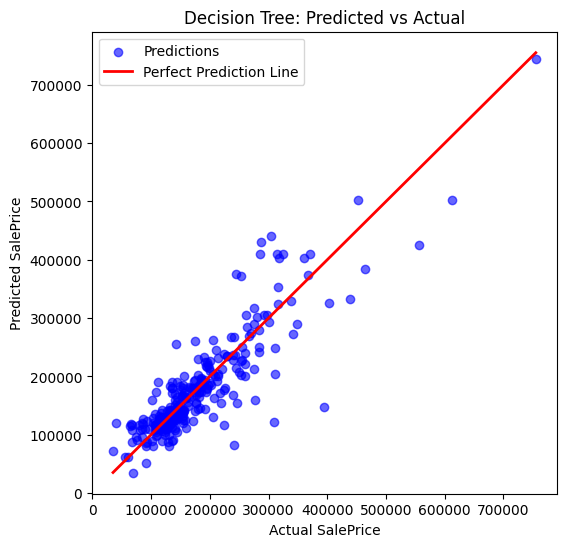

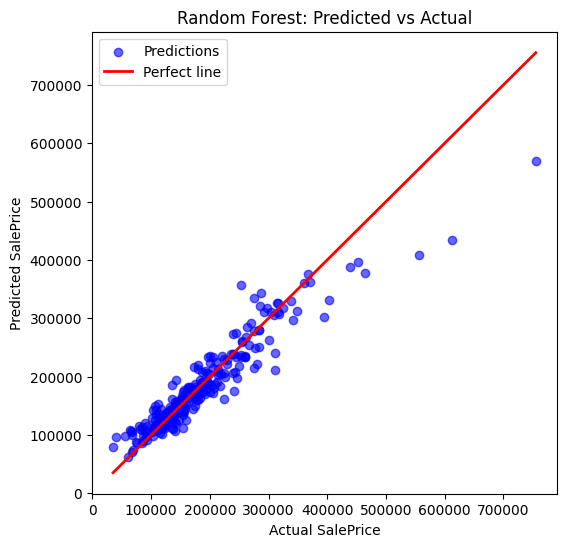

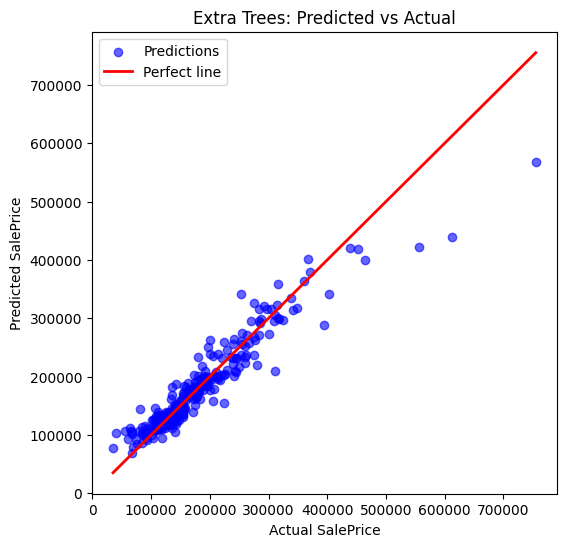

In [209]:
plt.figure(figsize=(6, 6))
plt.scatter(target_Test, y_pred_dt, color="blue", alpha=0.6, label="Predictions")
plt.plot(
    [target_Test.min(), target_Test.max()],
    [target_Test.min(), target_Test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction Line")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Decision Tree: Predicted vs Actual")
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(target_Test, y_pred_rf, color="blue", alpha=0.6, label="Predictions")
min_val = min(target_Test.min(), y_pred_rf.min())
max_val = max(target_Test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Perfect line")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Random Forest: Predicted vs Actual")
plt.legend()
plt.show()


plt.figure(figsize=(6, 6))
plt.scatter(target_Test, y_pred_et, color="blue", alpha=0.6, label="Predictions")
min_val = min(target_Test.min(), y_pred_et.min())
max_val = max(target_Test.max(), y_pred_et.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Perfect line")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Extra Trees: Predicted vs Actual")
plt.legend()
plt.show()

1. Decesion Tree:-
  * It is a single tree and single trees overfit.
  * Variance is high.
  * Plots are more scattered.
2. Random Forest :-  
  * Jump in performance.
  * Tighter dots near the perfect line.
3. Extra Tree:-
  * Better than Random Forest and Decesion Tree.
  * Slight improvement than the two.